Import Drive

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Important installtions before code runs

In [2]:
!apt-get install -y libta-lib0 libta-lib0-dev
!pip install TA-Lib


Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
E: Unable to locate package libta-lib0
E: Unable to locate package libta-lib0-dev
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.1/4.1 MB 40.9 MB/s eta 0:00:00


Models Code

In [6]:

#Imports

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.svm import SVC, SVR
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, mean_squared_error, mean_absolute_error, r2_score
import joblib
import talib

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, GRU, Dense, Dropout, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

np.random.seed(42)
tf.random.set_seed(42)

# Load Dataset

file_path = "/content/drive/MyDrive/KSE100-20years.csv"
df = pd.read_csv(file_path, parse_dates=["Date"])
df = df.sort_values("Date")
df = df[["Date","Open","High","Low","Close","Volume"]].dropna()

# Ensure numeric
for col in ["Open","High","Low","Close","Volume"]:
    if df[col].dtype=="object":
        df[col] = df[col].str.replace(",","").astype(float)

# Technical Indicators (TA-Lib)
df["MA5"] = df["Close"].rolling(5).mean()
df["MA10"] = df["Close"].rolling(10).mean()
df["MA20"] = df["Close"].rolling(20).mean()
df["MA50"] = df["Close"].rolling(50).mean()
df["STD10"] = df["Close"].rolling(10).std()
df["STD20"] = df["Close"].rolling(20).std()
df["Return"] = df["Close"].pct_change()
df["Momentum"] = df["Close"] - df["Close"].shift(10)

df["RSI"] = talib.RSI(df["Close"].values, timeperiod=14)
macd, macdsignal, macdhist = talib.MACD(df["Close"].values, fastperiod=12, slowperiod=26, signalperiod=9)
df["MACD"], df["MACDSignal"], df["MACDHist"] = macd, macdsignal, macdhist
upper, middle, lower = talib.BBANDS(df["Close"].values, timeperiod=20)
df["BB_upper"], df["BB_middle"], df["BB_lower"] = upper, middle, lower

# Lag features
for lag in range(1,31):
    df[f"lag_{lag}"] = df["Close"].shift(lag)

df = df.dropna().reset_index(drop=True)

# Feature sets
features_lstm = ["Close","MA5","MA10","MA20","MA50","STD10","STD20","Return","Momentum",
                 "RSI","MACD","MACDSignal","MACDHist","BB_upper","BB_middle","BB_lower"]
features_ml = features_lstm + [f"lag_{i}" for i in range(1,31)]

# Train/Test Split (80/20)
split_idx = int(0.8*len(df))
train_lstm = df.iloc[:split_idx][features_lstm].values
test_lstm  = df.iloc[split_idx:][features_lstm].values

#  Scaling & Sequences for LSTM
scaler_lstm = MinMaxScaler()
train_lstm_scaled = scaler_lstm.fit_transform(train_lstm)
test_lstm_scaled  = scaler_lstm.transform(test_lstm)

def make_seq(arr, lookback=60):
    X, y = [], []
    for i in range(lookback, len(arr)):
        X.append(arr[i-lookback:i])
        y.append(arr[i,0])
    return np.array(X), np.array(y)

lookback = 60
X_train_lstm, y_train_lstm = make_seq(train_lstm_scaled, lookback)
seed = train_lstm_scaled[-lookback+1:]
stacked_test = np.vstack([seed, test_lstm_scaled])
X_test_lstm, y_test_lstm = make_seq(stacked_test, lookback)

# Target scaler
y_scaler_lstm = MinMaxScaler()
y_train_scaled = y_scaler_lstm.fit_transform(y_train_lstm.reshape(-1,1))
y_test_scaled  = y_scaler_lstm.transform(y_test_lstm.reshape(-1,1))

#  Build LSTM Model (BiLSTM+GRU)
model = Sequential([
    Bidirectional(LSTM(128, return_sequences=True), input_shape=(X_train_lstm.shape[1], X_train_lstm.shape[2])),
    Dropout(0.2),
    GRU(64),
    Dropout(0.2),
    Dense(1)
])
model.compile(optimizer="adam", loss="mean_squared_error")

callbacks = [
    EarlyStopping(patience=10, restore_best_weights=True, monitor="val_loss"),
    ReduceLROnPlateau(patience=5, factor=0.5, min_lr=1e-5, monitor="val_loss")
]

history = model.fit(X_train_lstm, y_train_scaled, epochs=10, batch_size=32,
                    validation_split=0.1, callbacks=callbacks, verbose=1)

pred_scaled = model.predict(X_test_lstm, verbose=0).ravel()
pred_lstm = y_scaler_lstm.inverse_transform(pred_scaled.reshape(-1,1)).ravel()
true_lstm = y_scaler_lstm.inverse_transform(y_test_scaled.reshape(-1,1)).ravel()

#  ML Branch (RF & SVM)

train_ml = df.iloc[:split_idx][features_ml].values
test_ml  = df.iloc[split_idx:][features_ml].values

scaler_ml = MinMaxScaler()
train_ml_scaled = scaler_ml.fit_transform(train_ml)
test_ml_scaled  = scaler_ml.transform(test_ml)

def create_ml_sequences(dataset, target_col=0, lookback=60):
    X, y = [], []
    for i in range(lookback, len(dataset)):
        X.append(dataset[i-lookback:i,:])
        y.append(dataset[i,target_col])
    return np.array(X), np.array(y)

X_train_ml_3d, y_train_ml = create_ml_sequences(train_ml_scaled, target_col=0, lookback=lookback)
seed_ml = train_ml_scaled[-lookback:]
X_test_ml_3d, y_test_ml = create_ml_sequences(np.vstack([seed_ml, test_ml_scaled]), target_col=0, lookback=lookback)
X_test_ml_3d = X_test_ml_3d[-len(test_ml_scaled):]
y_test_ml = y_test_ml[-len(test_ml_scaled):]

# Flatten for classical ML

X_train_ml = X_train_ml_3d.reshape(X_train_ml_3d.shape[0], -1)
X_test_ml  = X_test_ml_3d.reshape(X_test_ml_3d.shape[0], -1)

# Feature selection via RF importance

temp_rf = RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1)
temp_rf.fit(X_train_ml, y_train_ml)
top_features_idx = np.argsort(temp_rf.feature_importances_)[-100:]
X_train_ml_sel = X_train_ml[:, top_features_idx]
X_test_ml_sel  = X_test_ml[:, top_features_idx]

# Scale target for ML branch
y_scaler_ml = MinMaxScaler()
y_train_ml_scaled = y_scaler_ml.fit_transform(y_train_ml.reshape(-1,1)).ravel()

#  GridSearch SVR
tscv = TimeSeriesSplit(n_splits=3)
param_grid = {"C":[1,10,100,200,500,1000], "gamma":[1e-3,1e-2,5e-2,0.1], "kernel":["rbf"]}
grid_svm = GridSearchCV(SVR(), param_grid, cv=tscv, scoring="r2", n_jobs=-1)
grid_svm.fit(X_train_ml_sel, y_train_ml_scaled)
svm_model = grid_svm.best_estimator_
svm_pred_scaled = svm_model.predict(X_test_ml_sel)
svm_pred = y_scaler_ml.inverse_transform(svm_pred_scaled.reshape(-1,1)).ravel()



# Align predictions & Ensemble
L = min(len(true_lstm), len(y_test_ml), len(pred_lstm), len(svm_pred))
true_aligned = y_test_ml[-L:]
lstm_aligned = pred_lstm[-L:]
svm_aligned  = svm_pred[-L:]



# Evaluation Functions
def evaluate_model(name, true, pred):
    mse = mean_squared_error(true, pred)
    mae = mean_absolute_error(true, pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(true, pred)
    print(f"\n{name} Performance:")
    print(f"MAE  = {mae:.4f}, RMSE = {rmse:.4f}, R² = {r2:.4f}")

evaluate_model("LSTM", true_aligned, lstm_aligned)
evaluate_model("SVM", true_aligned, svm_aligned)


Epoch 1/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 29s 215ms/step - loss: 0.0187 - val_loss: 0.0014 - learning_rate: 0.0010
Epoch 2/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 22s 200ms/step - loss: 0.0021 - val_loss: 0.0011 - learning_rate: 0.0010
Epoch 3/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 23s 200ms/step - loss: 0.0017 - val_loss: 0.0022 - learning_rate: 0.0010
Epoch 4/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 24s 211ms/step - loss: 0.0018 - val_loss: 0.0013 - learning_rate: 0.0010
Epoch 5/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 22s 192ms/step - loss: 0.0014 - val_loss: 5.7763e-04 - learning_rate: 0.0010
Epoch 6/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 41s 192ms/step - loss: 0.0013 - val_loss: 4.7976e-04 - learning_rate: 0.0010
Epoch 7/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 41s 192ms/step - loss: 0.0012 - val_loss: 0.0019 - learning_rate: 0.0010
Epoch 8/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 24s 214ms/step - loss: 0.0013 - val_loss: 0.0011 - learning_rate: 0.0010
Epoch 9/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 23s 202ms/step - loss: 9.8587e-04 - val_loss: 4.

ALL FIGURES


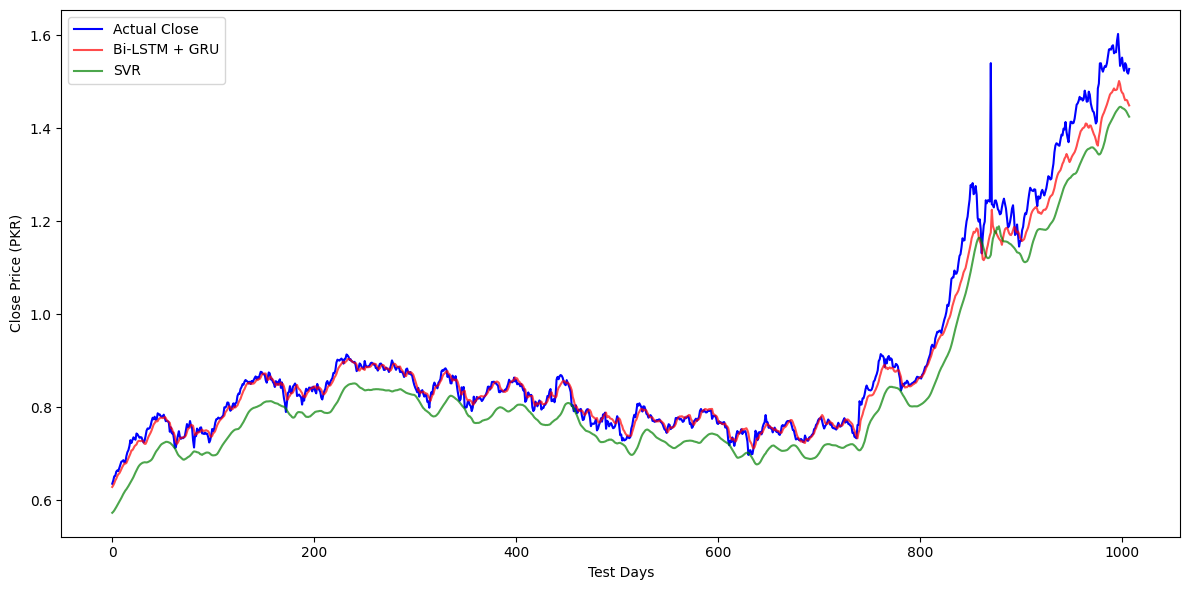

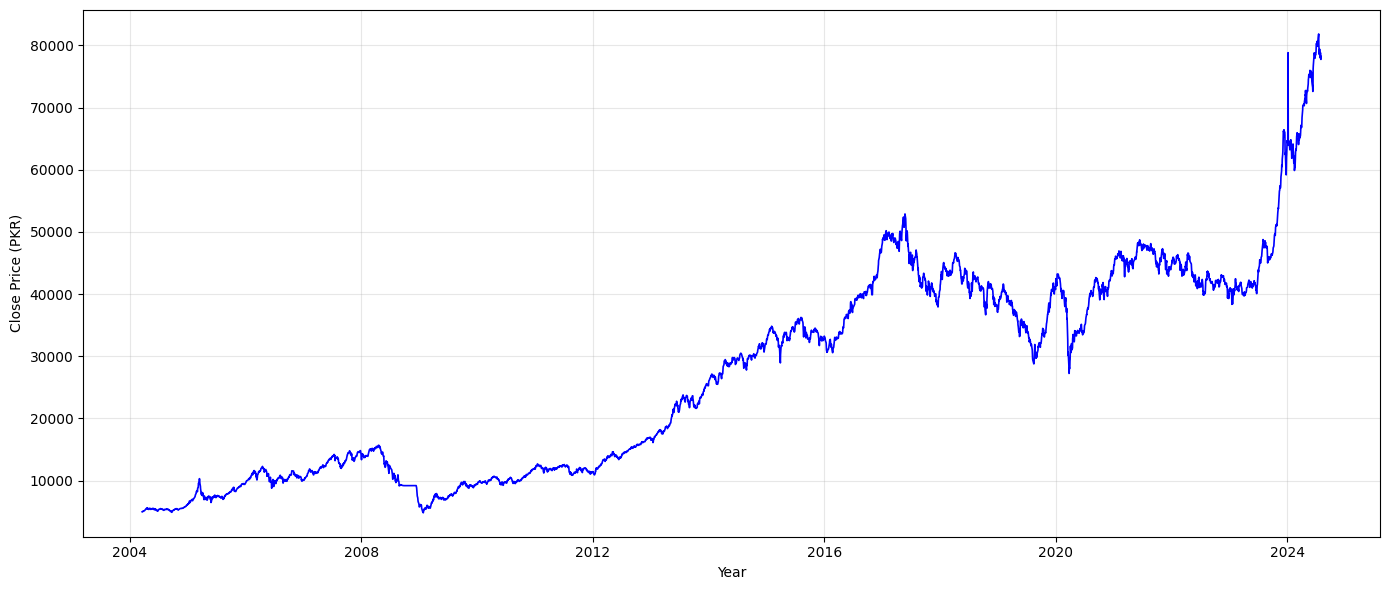

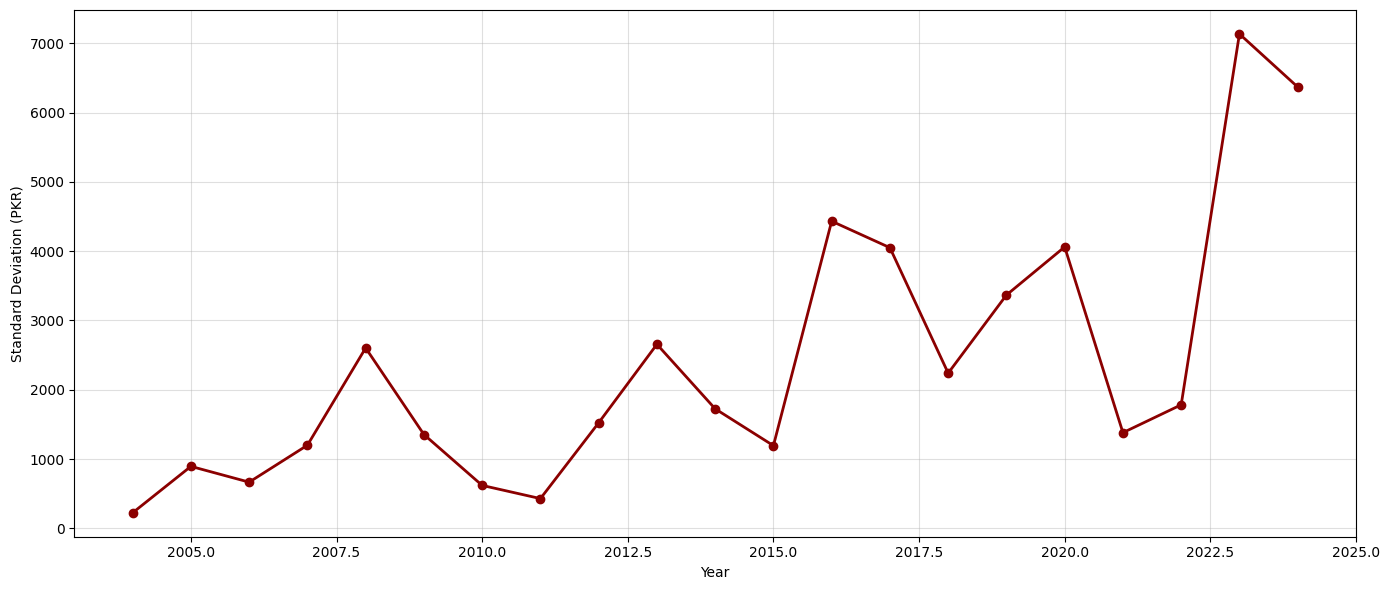

<Figure size 3200x900 with 0 Axes>

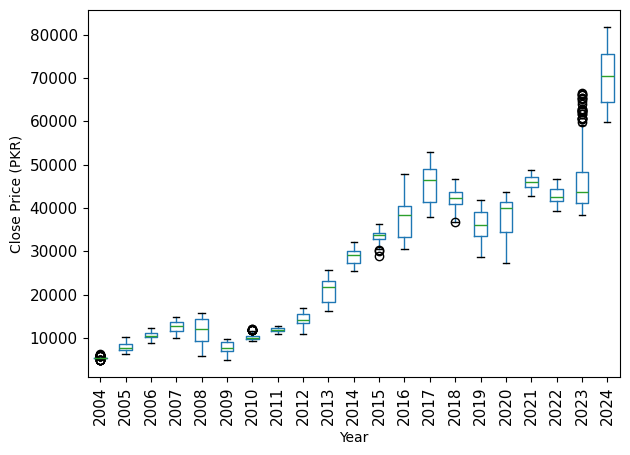

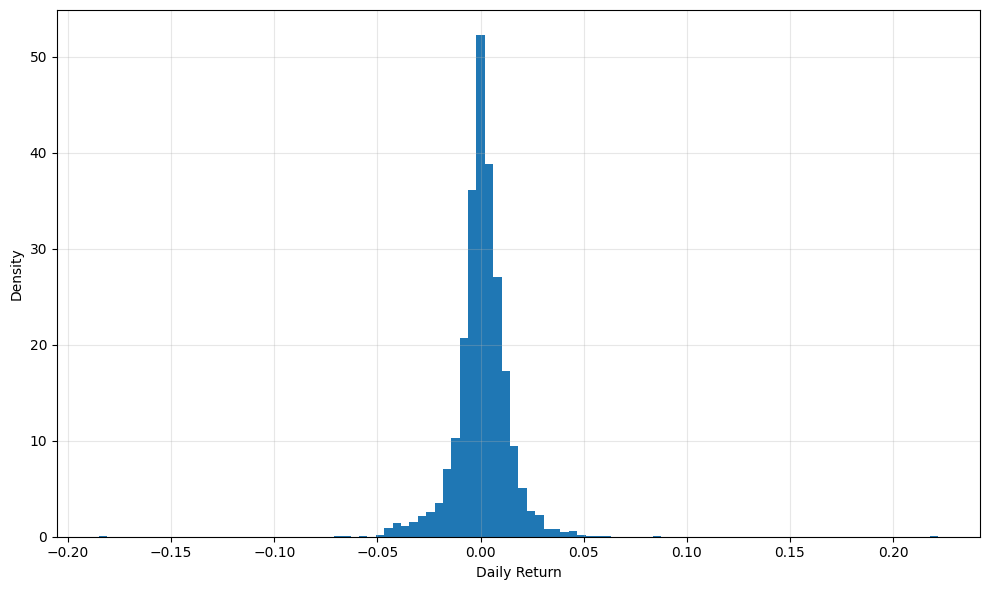

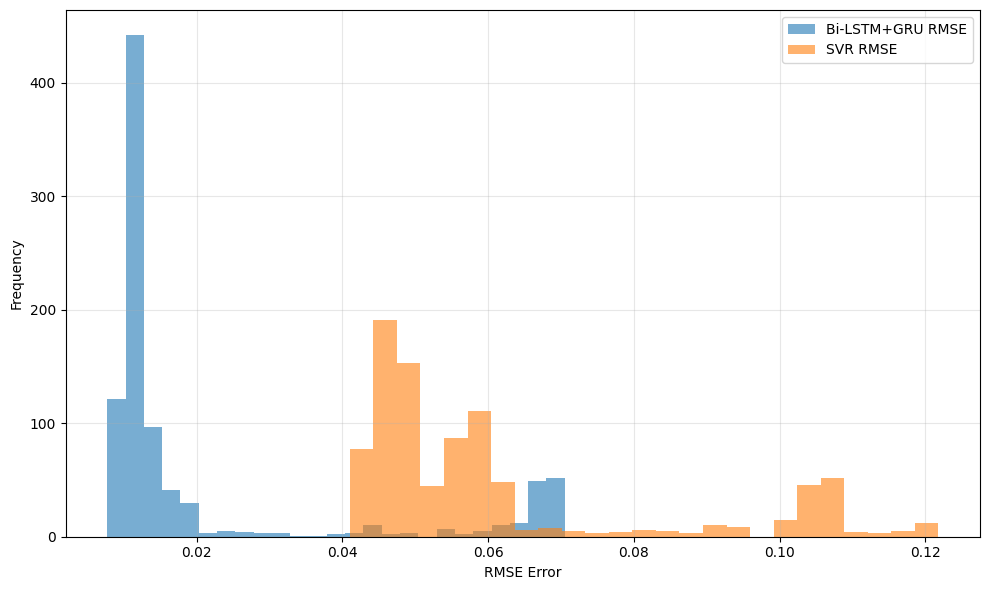

,count,mean,std,min,25%,50%,75%,max,skewness,kurtosis
Open,5044.0,2.704104e+04,1.674781e+04,4795.85,1.115370e+04,2.872386e+04,4.128238e+04,8.192171e+04,0.450036,-0.579118
High,5044.0,2.721133e+04,1.684274e+04,4957.66,1.126591e+04,2.894259e+04,4.150219e+04,8.193983e+04,0.451267,-0.575234
Low,5044.0,2.685039e+04,1.663957e+04,4781.78,1.106866e+04,2.852433e+04,4.100828e+04,8.141811e+04,0.450461,-0.576193
Close,5044.0,2.702596e+04,1.673800e+04,4815.34,1.115271e+04,2.874694e+04,4.123853e+04,8.183986e+04,0.450206,-0.578390
Volume,5044.0,1.796268e+08,1.558717e+08,0.00,8.255643e+07,1.327738e+08,2.238657e+08,1.492189e+09,2.672009,10.994400


In [8]:
df["Year"] = df["Date"].dt.year



# Accuracy Graph

plt.figure(figsize=(12,6))
plt.plot(true_aligned, label="Actual Close", color='blue')
plt.plot(lstm_aligned, label="Bi-LSTM + GRU", color='red', alpha=0.7)
plt.plot(svm_aligned, label="SVR", color='green', alpha=0.7)


plt.title("")
plt.xlabel("Test Days")
plt.ylabel("Close Price (PKR)")
plt.legend()
plt.tight_layout()
plt.show()

# Close Price fig


plt.figure(figsize=(14,6))
plt.plot(df["Date"], df["Close"], color="blue", linewidth=1.2)
plt.title("", fontsize=18, fontweight="bold")
plt.xlabel("Year")
plt.ylabel("Close Price (PKR)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

#yearly_volatility Fig

yearly_volatility = df.groupby("Year")["Close"].std()

plt.figure(figsize=(14,6))
plt.plot(yearly_volatility.index, yearly_volatility.values,
         marker="o", linewidth=2, color="darkred")

plt.title("", fontsize=14, fontweight="bold")
plt.xlabel("Year")
plt.ylabel("Standard Deviation (PKR)")
plt.grid(alpha=0.4)
plt.tight_layout()
plt.show()

# Boxplot fig

plt.figure(figsize=(32, 9))

df.boxplot(column="Close", by="Year", grid=False)

plt.suptitle("")
plt.title("", fontsize=18, fontweight="bold")

plt.xlabel("Year")
plt.ylabel("Close Price (PKR)")

plt.xticks(rotation=90, fontsize=11)
plt.yticks(fontsize=11)

plt.tight_layout()
plt.show()

 # Density Fig

plt.figure(figsize=(10,6))
plt.hist(df["Return"].dropna(), bins=100, density=True)
plt.title("", fontsize=14, fontweight="bold")
plt.xlabel("Daily Return")
plt.ylabel("Density")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# ================================
# RMSE DISTRIBUTION (Rolling)
# ================================

def rolling_rmse(true, pred, window=1000):
    rmses = []
    for i in range(window, len(true)):
        rmse = np.sqrt(mean_squared_error(true[i-window:i], pred[i-window:i]))
        rmses.append(rmse)
    return np.array(rmses)

# Rolling RMSE for each model
window = 100
rmse_lstm = rolling_rmse(true_aligned, lstm_aligned, window)
rmse_svm  = rolling_rmse(true_aligned, svm_aligned, window)


# ================================
# RMSE DISTRIBUTION PLOT
# ================================


plt.figure(figsize=(10,6))

plt.hist(rmse_lstm, bins=25, alpha=0.6, label="Bi-LSTM+GRU RMSE")
plt.hist(rmse_svm,  bins=25, alpha=0.6, label="SVR RMSE")


plt.xlabel("RMSE Error")
plt.ylabel("Frequency")
plt.title("")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

summary_stats = df[["Open","High","Low","Close","Volume"]].describe().T
summary_stats["skewness"] = df[["Open","High","Low","Close","Volume"]].skew()
summary_stats["kurtosis"] = df[["Open","High","Low","Close","Volume"]].kurtosis()

summary_stats

LSTM and Gru seperated test

Epoch 1/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 17s 124ms/step - loss: 0.0139 - val_loss: 0.0018 - learning_rate: 0.0010
Epoch 2/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 15s 134ms/step - loss: 0.0017 - val_loss: 8.2745e-04 - learning_rate: 0.0010
Epoch 3/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 14s 121ms/step - loss: 0.0014 - val_loss: 0.0034 - learning_rate: 0.0010
Epoch 4/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 21s 121ms/step - loss: 0.0014 - val_loss: 0.0012 - learning_rate: 0.0010
Epoch 5/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 13s 120ms/step - loss: 0.0012 - val_loss: 7.3420e-04 - learning_rate: 0.0010
Epoch 6/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 13s 115ms/step - loss: 0.0013 - val_loss: 0.0014 - learning_rate: 0.0010
Epoch 7/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 13s 116ms/step - loss: 0.0011 - val_loss: 7.2445e-04 - learning_rate: 0.0010
Epoch 8/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 13s 118ms/step - loss: 0.0010 - val_loss: 0.0026 - learning_rate: 0.0010
Epoch 9/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 14s 123ms/step - loss: 0.0010 - val_loss: 8.

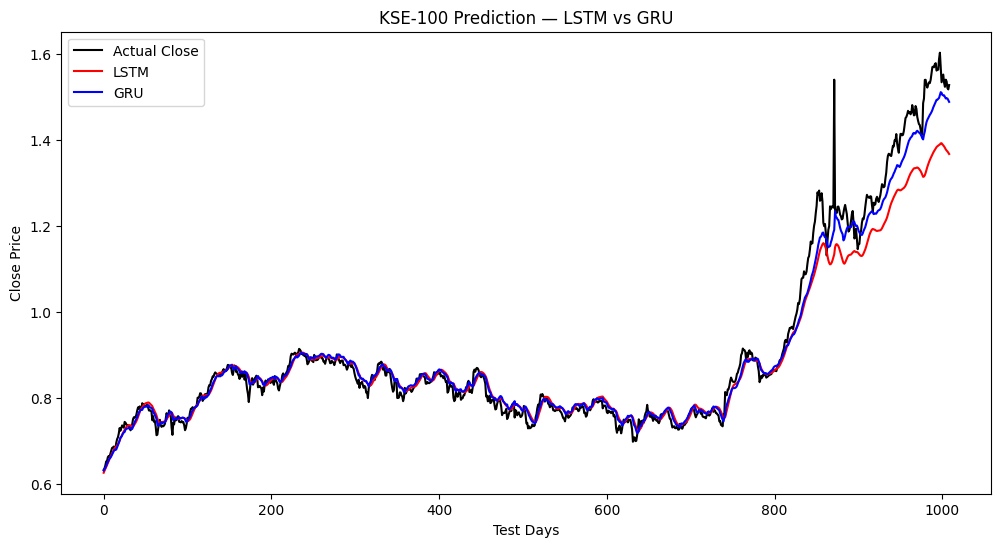


LSTM Performance:
MAE  = 0.0307
RMSE = 0.0541
R²   = 0.9356

GRU Performance:
MAE  = 0.0192
RMSE = 0.0305
R²   = 0.9795


In [ ]:
# ======================================================================
# KSE-100 PREDICTION — LSTM MODEL + GRU MODEL (SEPARATE)
# ======================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

from sklearn.preprocessing import MinMaxScaler
import talib
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, GRU, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
np.random.seed(42)
tf.random.set_seed(42)

# ----------------------------------------------------------------------
# LOAD DATA
# ----------------------------------------------------------------------
file_path = "/content/drive/MyDrive/KSE100-20years.csv"
df = pd.read_csv(file_path, parse_dates=["Date"])
df = df.sort_values("Date")
df = df[["Date","Open","High","Low","Close","Volume"]].dropna()

for col in ["Open","High","Low","Close","Volume"]:
    if df[col].dtype == "object":
        df[col] = df[col].str.replace(",", "").astype(float)

# ----------------------------------------------------------------------
# TECHNICAL INDICATORS
# ----------------------------------------------------------------------
df["MA5"] = df["Close"].rolling(5).mean()
df["MA10"] = df["Close"].rolling(10).mean()
df["MA20"] = df["Close"].rolling(20).mean()
df["MA50"] = df["Close"].rolling(50).mean()

df["STD10"] = df["Close"].rolling(10).std()
df["STD20"] = df["Close"].rolling(20).std()

df["Return"] = df["Close"].pct_change()
df["Momentum"] = df["Close"] - df["Close"].shift(10)

df["RSI"] = talib.RSI(df["Close"].values, timeperiod=14)
macd, macdsignal, macdhist = talib.MACD(df["Close"].values)
df["MACD"], df["MACDSignal"], df["MACDHist"] = macd, macdsignal, macdhist

upper, middle, lower = talib.BBANDS(df["Close"].values)
df["BB_upper"], df["BB_middle"], df["BB_lower"] = upper, middle, lower

df = df.dropna().reset_index(drop=True)

# ----------------------------------------------------------------------
# FEATURES FOR DL
# ----------------------------------------------------------------------
features = [
    "Close","MA5","MA10","MA20","MA50","STD10","STD20",
    "Return","Momentum","RSI","MACD","MACDSignal","MACDHist",
    "BB_upper","BB_middle","BB_lower"
]

# ----------------------------------------------------------------------
# TRAIN–TEST SPLIT
# ----------------------------------------------------------------------
split_idx = int(len(df) * 0.8)

train = df.iloc[:split_idx][features].values
test  = df.iloc[split_idx:][features].values

# ----------------------------------------------------------------------
# SCALING
# ----------------------------------------------------------------------
scaler = MinMaxScaler()
train_scaled = scaler.fit_transform(train)
test_scaled  = scaler.transform(test)

# ----------------------------------------------------------------------
# SEQUENCE GENERATOR
# ----------------------------------------------------------------------
def create_sequences(data, lookback=60):
    X, y = [], []
    for i in range(lookback, len(data)):
        X.append(data[i-lookback:i])
        y.append(data[i, 0])  # Close price
    return np.array(X), np.array(y)

lookback = 60

X_train, y_train = create_sequences(train_scaled, lookback)

# allow test sequence continuity
seed = train_scaled[-lookback:]
stacked = np.vstack([seed, test_scaled])
X_test, y_test = create_sequences(stacked, lookback)

# ----------------------------------------------------------------------
# TARGET SCALER
# ----------------------------------------------------------------------
y_scaler = MinMaxScaler()
y_train_scaled = y_scaler.fit_transform(y_train.reshape(-1,1))
y_test_scaled  = y_scaler.transform(y_test.reshape(-1,1))

# ======================================================================
# 1️⃣ LSTM MODEL
# ======================================================================
lstm_model = Sequential([
    LSTM(128, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])),
    Dropout(0.2),
    LSTM(64),
    Dropout(0.2),
    Dense(1)
])

lstm_model.compile(optimizer="adam", loss="mse")

callbacks = [
    EarlyStopping(patience=10, restore_best_weights=True, monitor="val_loss"),
    ReduceLROnPlateau(patience=5, factor=0.5, min_lr=1e-5, monitor="val_loss")
]

lstm_model.fit(
    X_train, y_train_scaled,
    epochs=10, batch_size=32,
    validation_split=0.1, callbacks=callbacks, verbose=1
)

# LSTM Predictions
lstm_pred_scaled = lstm_model.predict(X_test).ravel()
lstm_pred = y_scaler.inverse_transform(lstm_pred_scaled.reshape(-1,1)).ravel()

# ======================================================================
# 2️⃣ GRU MODEL
# ======================================================================
gru_model = Sequential([
    GRU(128, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])),
    Dropout(0.2),
    GRU(64),
    Dropout(0.2),
    Dense(1)
])

gru_model.compile(optimizer="adam", loss="mse")

gru_model.fit(
    X_train, y_train_scaled,
    epochs=10, batch_size=32,
    validation_split=0.1, callbacks=callbacks, verbose=1
)

# GRU Predictions
gru_pred_scaled = gru_model.predict(X_test).ravel()
gru_pred = y_scaler.inverse_transform(gru_pred_scaled.reshape(-1,1)).ravel()

# ======================================================================
# VISUALIZATION
# ======================================================================
plt.figure(figsize=(12,6))
plt.plot(y_test, label="Actual Close", color="black")
plt.plot(lstm_pred, label="LSTM", color="red")
plt.plot(gru_pred, label="GRU", color="blue")
plt.title("KSE-100 Prediction — LSTM vs GRU")
plt.xlabel("Test Days")
plt.ylabel("Close Price")
plt.legend()
plt.show()

# ======================================================================


def evaluate_model(name, true, pred):
    mse = mean_squared_error(true, pred)
    mae = mean_absolute_error(true, pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(true, pred)

    print(f"\n{name} Performance:")
    print(f"MAE  = {mae:.4f}")
    print(f"RMSE = {rmse:.4f}")
    print(f"R²   = {r2:.4f}")

evaluate_model("LSTM", y_test, lstm_pred)
evaluate_model("GRU", y_test, gru_pred)

Cross Validation Using TimeSPlit




LSTM Performance:
MAE  = 1021.7972
RMSE = 1387.7893
R²   = 0.9817
Directional Accuracy (up/down) = 53.23%

SVR Performance:
MAE  = 2893.3522
RMSE = 3332.3204
R²   = 0.8943
Directional Accuracy (up/down) = 51.94%


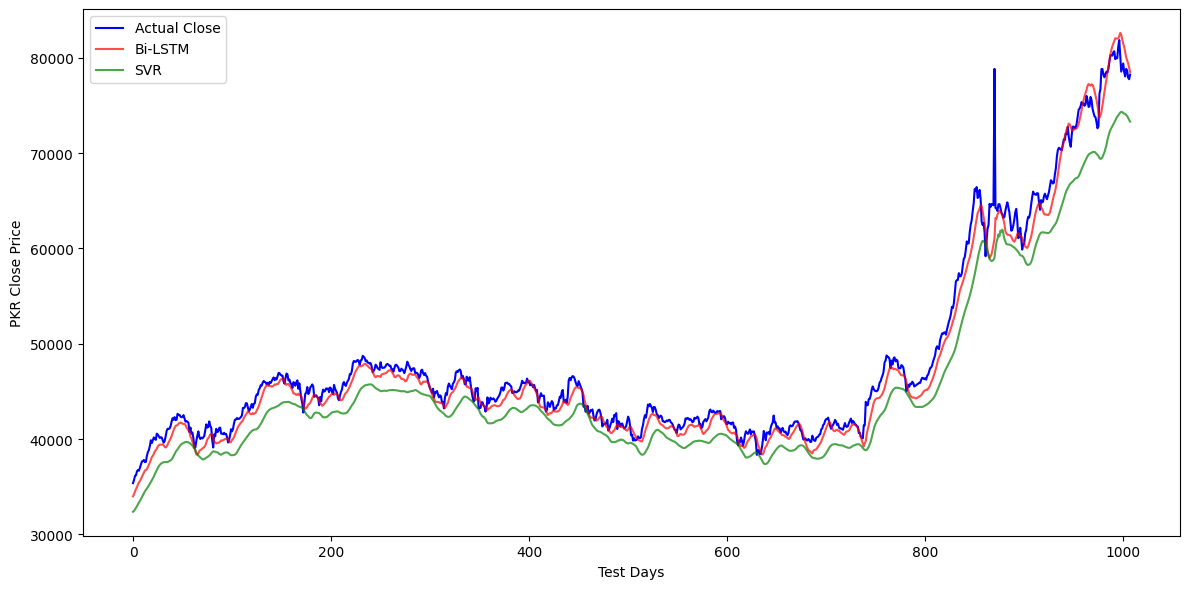

In [5]:
# ============================================
# KSE-100 Full Prediction Pipeline
# LSTM + RF + SVM + Ensemble (Direction + R²)
# ============================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score
)
import talib

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.regularizers import l2

np.random.seed(42)
tf.random.set_seed(42)

# ----------------------------
# Load Dataset
# ----------------------------
file_path = "/content/drive/MyDrive/KSE100-20years.csv"
df = pd.read_csv(file_path, parse_dates=["Date"])
df = df.sort_values("Date")
df = df[["Date","Open","High","Low","Close","Volume"]].dropna()

# Ensure numeric
for col in ["Open","High","Low","Close","Volume"]:
    if df[col].dtype == "object":
        df[col] = df[col].str.replace(",","").astype(float)

# ----------------------------
# Technical Indicators
# ----------------------------
df["MA5"]   = df["Close"].rolling(5).mean()
df["MA10"]  = df["Close"].rolling(10).mean()
df["MA20"]  = df["Close"].rolling(20).mean()
df["MA50"]  = df["Close"].rolling(50).mean()
df["STD10"] = df["Close"].rolling(10).std()
df["STD20"] = df["Close"].rolling(20).std()
df["Return"]   = df["Close"].pct_change()
df["Momentum"] = df["Close"] - df["Close"].shift(10)

df["RSI"] = talib.RSI(df["Close"].values, timeperiod=14)
macd, macdsignal, macdhist = talib.MACD(
    df["Close"].values, fastperiod=12, slowperiod=26, signalperiod=9
)
df["MACD"], df["MACDSignal"], df["MACDHist"] = macd, macdsignal, macdhist
upper, middle, lower = talib.BBANDS(df["Close"].values, timeperiod=20)
df["BB_upper"], df["BB_middle"], df["BB_lower"] = upper, middle, lower

# Lag features for RF/SVM
for lag in range(1, 31):
    df[f"lag_{lag}"] = df["Close"].shift(lag)

df = df.dropna().reset_index(drop=True)

# ----------------------------
# Feature sets
# ----------------------------
features_lstm = [
    "Close","MA5","MA10","MA20","MA50","STD10","STD20","Return","Momentum",
    "RSI","MACD","MACDSignal","MACDHist","BB_upper","BB_middle","BB_lower"
]
features_ml = features_lstm + [f"lag_{i}" for i in range(1, 31)]

# ----------------------------
# Train/Test split
# ----------------------------
split_idx = int(0.8 * len(df))

train_lstm = df.iloc[:split_idx][features_lstm].values
test_lstm  = df.iloc[split_idx:][features_lstm].values

train_ml = df.iloc[:split_idx][features_ml].values
test_ml  = df.iloc[split_idx:][features_ml].values

lookback = 60

# ----------------------------
# Scaling (features)
# ----------------------------
scaler_lstm = MinMaxScaler()
train_lstm_scaled = scaler_lstm.fit_transform(train_lstm)
test_lstm_scaled  = scaler_lstm.transform(test_lstm)

scaler_ml = MinMaxScaler()
train_ml_scaled = scaler_ml.fit_transform(train_ml)
test_ml_scaled  = scaler_ml.transform(test_ml)

# ----------------------------
# Target scalers (unscaled Close)
# ----------------------------
y_train_close_unscaled = df["Close"].iloc[lookback:split_idx].values.reshape(-1, 1)
y_scaler_lstm = MinMaxScaler()
y_scaler_ml   = MinMaxScaler()
y_scaler_lstm.fit(y_train_close_unscaled)
y_scaler_ml.fit(y_train_close_unscaled)

# ----------------------------
# Sequence helpers
# ----------------------------
def make_seq(arr, lookback):
    X, y = [], []
    for i in range(lookback, len(arr)):
        X.append(arr[i-lookback:i])
        y.append(arr[i, 0])    # scaled Close
    return np.array(X), np.array(y)

def create_ml_sequences(dataset, target_col, lookback):
    X, y = [], []
    for i in range(lookback, len(dataset)):
        X.append(dataset[i-lookback:i, :])
        y.append(dataset[i, target_col])  # scaled Close
    return np.array(X), np.array(y)

# ----------------------------
# Build LSTM train/test sequences
# ----------------------------
X_train_lstm, y_train_lstm_scaled = make_seq(train_lstm_scaled, lookback)

seed_lstm = train_lstm_scaled[-lookback+1:]
stacked_test_lstm = np.vstack([seed_lstm, test_lstm_scaled])
X_test_lstm, y_test_lstm_scaled = make_seq(stacked_test_lstm, lookback)

# ----------------------------
# LSTM model (BiLSTM, regression)
# ----------------------------
model_lstm = Sequential([
    Bidirectional(LSTM(
        64,
        return_sequences=False,
        kernel_regularizer=l2(1e-4)
    ), input_shape=(X_train_lstm.shape[1], X_train_lstm.shape[2])),
    Dropout(0.3),
    Dense(32, activation="relu"),
    Dense(1)
])

model_lstm.compile(optimizer="adam", loss="mean_squared_error")

callbacks = [
    EarlyStopping(patience=10, restore_best_weights=True, monitor="val_loss"),
    ReduceLROnPlateau(patience=5, factor=0.5, min_lr=1e-5, monitor="val_loss")
]

history = model_lstm.fit(
    X_train_lstm,
    y_train_lstm_scaled,
    validation_split=0.1,
    epochs=40,
    batch_size=32,
    callbacks=callbacks,
    verbose=0
)

# LSTM predictions (inverse-transform to price)
lstm_pred_scaled = model_lstm.predict(X_test_lstm, verbose=0).ravel()
lstm_pred = y_scaler_lstm.inverse_transform(
    lstm_pred_scaled.reshape(-1, 1)
).ravel()

true_lstm_scaled = y_test_lstm_scaled
true_lstm = y_scaler_lstm.inverse_transform(
    true_lstm_scaled.reshape(-1, 1)
).ravel()

# ----------------------------
# ML sequences (for RF & SVM)
# ----------------------------
X_train_ml_3d, y_train_ml_scaled = create_ml_sequences(
    train_ml_scaled, target_col=0, lookback=lookback
)

seed_ml = train_ml_scaled[-lookback:]
stacked_test_ml = np.vstack([seed_ml, test_ml_scaled])
X_test_ml_3d, y_test_ml_scaled = create_ml_sequences(
    stacked_test_ml, target_col=0, lookback=lookback
)

# flatten sequences
X_train_ml = X_train_ml_3d.reshape(X_train_ml_3d.shape[0], -1)
X_test_ml  = X_test_ml_3d.reshape(X_test_ml_3d.shape[0], -1)

# target scaler for ML branch
y_train_ml_unscaled = df["Close"].iloc[lookback:split_idx].values.reshape(-1, 1)
y_scaler_ml = MinMaxScaler()
y_train_ml_scaled_forfit = y_scaler_ml.fit_transform(y_train_ml_unscaled).ravel()

# ----------------------------
# RF feature selection
# ----------------------------
temp_rf = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)
temp_rf.fit(X_train_ml, y_train_ml_scaled_forfit)
# choose top 100 features by importance
top_features_idx = np.argsort(temp_rf.feature_importances_)[-100:]

X_train_ml_sel = X_train_ml[:, top_features_idx]
X_test_ml_sel  = X_test_ml[:, top_features_idx]

# ----------------------------
# Final RF model (on selected features)
# ----------------------------
rf_model = RandomForestRegressor(
    n_estimators=500,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train_ml_sel, y_train_ml_scaled_forfit)

rf_pred_scaled = rf_model.predict(X_test_ml_sel)
rf_pred = y_scaler_ml.inverse_transform(
    rf_pred_scaled.reshape(-1, 1)
).ravel()

# ----------------------------
# SVR with TimeSeries CV
# ----------------------------
tscv = TimeSeriesSplit(n_splits=5)
param_grid = {
    "C": [10, 50, 100],
    "gamma": [1e-3, 5e-3, 1e-2],
    "kernel": ["rbf"]
}
grid_svm = GridSearchCV(
    SVR(),
    param_grid,
    cv=tscv,
    scoring="r2",
    n_jobs=-1,
    verbose=0
)
grid_svm.fit(X_train_ml_sel, y_train_ml_scaled_forfit)
svm_model = grid_svm.best_estimator_

svm_pred_scaled = svm_model.predict(X_test_ml_sel)
svm_pred = y_scaler_ml.inverse_transform(
    svm_pred_scaled.reshape(-1, 1)
).ravel()

# ----------------------------
# Align series & Ensemble
# ----------------------------
L = min(len(true_lstm), len(lstm_pred), len(rf_pred), len(svm_pred))

true_aligned = true_lstm[-L:]
lstm_aligned = lstm_pred[-L:]
rf_aligned   = rf_pred[-L:]
svm_aligned  = svm_pred[-L:]


# ----------------------------
# Metrics
# ----------------------------
def evaluate_model(name, true, pred):
    mse  = mean_squared_error(true, pred)
    mae  = mean_absolute_error(true, pred)
    rmse = np.sqrt(mse)
    r2   = r2_score(true, pred)
    print(f"\n{name} Performance:")
    print(f"MAE  = {mae:.4f}")
    print(f"RMSE = {rmse:.4f}")
    print(f"R²   = {r2:.4f}")

    # directional accuracy (up/down of price)
    true_dir = np.sign(np.diff(true))
    pred_dir = np.sign(np.diff(pred))
    dir_acc  = (true_dir == pred_dir).mean() * 100
    print(f"Directional Accuracy (up/down) = {dir_acc:.2f}%")

evaluate_model("LSTM", true_aligned, lstm_aligned)

evaluate_model("SVR", true_aligned, svm_aligned)


# ----------------------------
# Visualization
# ----------------------------
plt.figure(figsize=(12,6))
plt.plot(true_aligned,      label="Actual Close", color="blue")
plt.plot(lstm_aligned,      label="Bi-LSTM",         color="red",   alpha=0.7)
plt.plot(svm_aligned,       label="SVR",          color="green", alpha=0.7)

plt.xlabel("Test Days")
plt.ylabel("PKR Close Price")
plt.legend()
plt.tight_layout()
plt.show()
